In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings for python figures
plt.style.use('classic')

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'''
    \usepackage[T1]{fontenc}
    \usepackage{lmodern}
    \usepackage[utf8]{inputenc}
    \usepackage{amsmath}
    \usepackage{amssymb}
    \usepackage{siunitx}
    \usepackage{sfmath}
    '''
})
plt.rcParams.update({
    # Figure settings
    'figure.dpi': 300,
    'figure.figsize': (10/2.54, 6/2.54),  # 10x6 cm in inches (1 figure per line)
    # 'figure.figsize': (8/2.54, 6/2.54),  # 10x6 cm in inches (2 figures per line)
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    # 'mathtext.fontset': 'cm',
    'figure.constrained_layout.use': True,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
    "xtick.minor.width":0,
    "ytick.minor.width": 0,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,  

    # Legend
    'legend.frameon': False,
    'legend.title_fontsize': 8,
    'legend.fontsize': 8,
    'legend.handlelength': 2,
    'legend.loc': 'best',
    'legend.numpoints': 1,

    # Line style
    'lines.linestyle': '-',
    'lines.linewidth': 1,
    'lines.markersize': 4,
    'lines.markeredgecolor': 'white',
    'lines.markeredgewidth': 0.5,
})



Fitted parameters: A = 7.92e+10, Ea = 0.62 eV


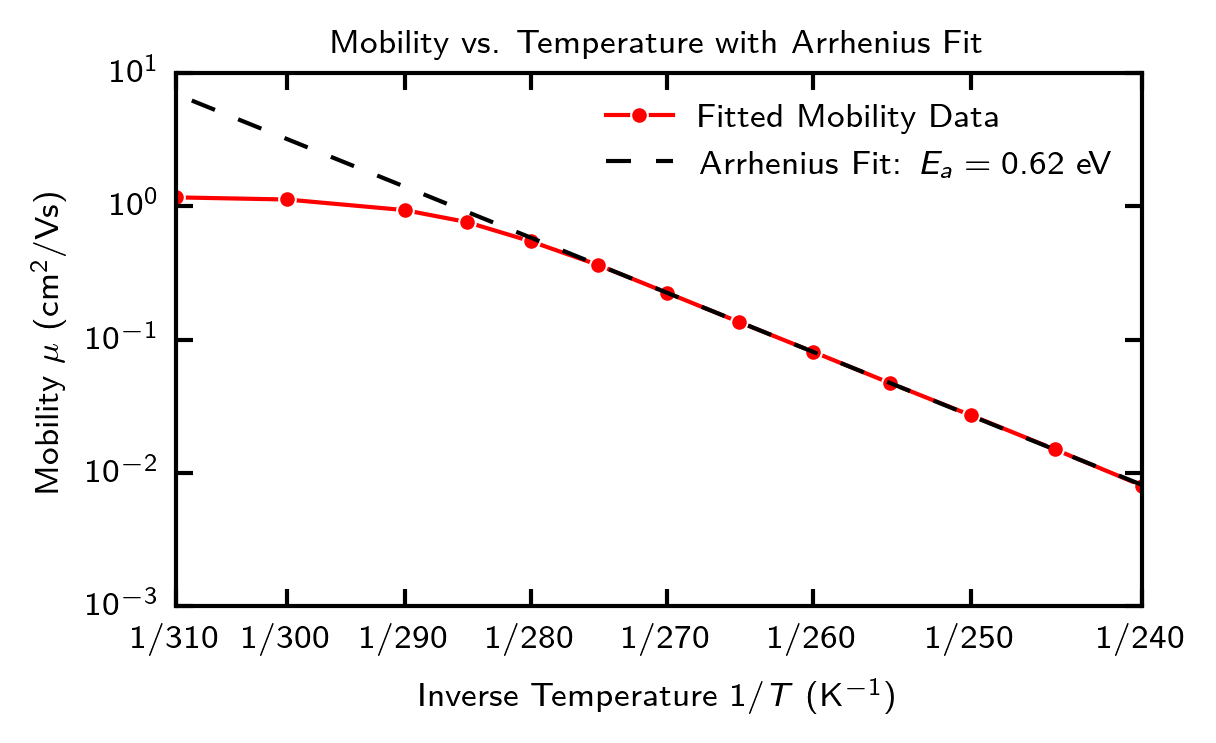

In [4]:
T_1 = np.array([310,300,290, 285,280,275,270,265,260,255, 250, 245, 240])
mu_1 = np.array([1.169, 1.127, 0.938, 0.763, 0.546, 0.364, 0.225, 0.136, 0.081, 0.047, 0.027, 0.015, 0.008]) 





inv_T_ticks = 1 / np.array([310,300,290,280,270,260, 250, 240], dtype=float)
inv_T_ticklabels = [f'1/{temp}' for temp in [310, 300, 290, 280, 270, 260, 250, 240]]

def arrhenius(T, A, Ea):
    k_B = 8.617333262145e-5  # Boltzmann constant in eV/K
    return A * np.exp(-Ea / (k_B * T))


# fit only the last 6 points
T_fit_data = np.array(T_1[-7:], dtype=float)
mu_fit_data = np.array(mu_1[-7:], dtype=float)

popt, pcov = curve_fit(arrhenius, T_fit_data, mu_fit_data, p0=(1e-3, 0.1))
A_fit, Ea_fit = popt
print(f"Fitted parameters: A = {A_fit:.2e}, Ea = {Ea_fit:.2f} eV")

T_fit = np.linspace(240, 310, 100)
mu_fit = arrhenius(T_fit, *popt)

plt.semilogy(1/T_1, mu_1, marker='o', linestyle='-', lw=1, color='red', label='Fitted Mobility Data')
# plt.semilogy(inv_T_2, mu_2, marker='s', linestyle='-', lw=2, color='blue',
#              markeredgecolor="white", markeredgewidth=1, markersize=8, label='Heating')
plt.plot(1/T_fit, mu_fit, linestyle='--', lw=1, color='black', label=rf'Arrhenius Fit: $E_a = {Ea_fit:.2f}$ eV')
plt.xlabel(r'Inverse Temperature $1/T$ (K$^{-1}$)')
plt.ylabel(r'Mobility $\mu$ (cm$^2$/Vs)')
plt.xticks(inv_T_ticks, inv_T_ticklabels)
plt.xlim(1/310, 1/240)
plt.title('Mobility vs. Temperature with Arrhenius Fit')
plt.legend()
plt.savefig('arrhenius.eps', format='eps')
plt.savefig('arrhenius.png', format='png', dpi=600)
plt.show()